# T1.A1.1 — Adquisición y Mejora Básica de una Imagen Digital
## Objetivo

Analizar los conceptos básicos de adquisición y representación digital de imágenes, mediante la identificación de formatos, modelos de color y estructuras de datos digitales, en un entorno académico guiado, con el propósito de establecer una base conceptual sólida que permita el procesamiento adecuado de imágenes en aplicaciones de visión por computadora.

---

## Instrucciones para el participante

1. Ejecuta cada celda **en orden** con `Shift + Enter`.
2. Completa las celdas marcadas con 📝 — son parte de tu portafolio de evidencias.
3. **No borres** las celdas de código base; puedes agregar celdas nuevas si lo necesitas.
4. Al finalizar, exporta este notebook como PDF (`Archivo → Imprimir → Guardar como PDF`).
5. Nombre de entrega: `T1_A1_ApellidoNombre.pdf`

---

### Contenido del Tema 1 que cubre esta actividad
- **1.1** Introducción al procesamiento de imágenes
- **1.2** Adquisición de imágenes
- **1.3** Formato de imagen y representación digital
- **1.4** Mejoras básicas de una imagen

---
## PASO 1 — Preparación del entorno de trabajo
**Valor: 3% | Tiempo estimado: 1 hora**

Verifica que las bibliotecas necesarias están disponibles.  
Si trabajas en entorno local y faltan bibliotecas, descomenta e instala:

In [1]:
# Instalación (descomenta si es necesario)
# !pip install numpy matplotlib opencv-python

import cv2
import numpy as np
import matplotlib.pyplot as plt
import os, sys

# Verificación de versiones
import matplotlib as mpl
print('=' * 45)
print('  ✅ ENTORNO VERIFICADO CORRECTAMENTE')
print('=' * 45)
print(f'  Python     : {sys.version.split()[0]}')
print(f'  NumPy      : {np.__version__}')
print(f'  OpenCV     : {cv2.__version__}')
print(f'  Matplotlib : {mpl.__version__}')
print('=' * 45)

  ✅ ENTORNO VERIFICADO CORRECTAMENTE
  Python     : 3.10.11
  NumPy      : 1.26.4
  OpenCV     : 4.13.0
  Matplotlib : 3.10.8


---
## PASO 2 — Introducción a la actividad
**Valor: 3% | Tiempo estimado: 1 hora**

### Conceptos clave del Tema 1

| Concepto | Definición |
|---|---|
| **Imagen digital** | Matriz de píxeles donde cada elemento almacena un valor de intensidad o color |
| **Píxel** | Unidad mínima de una imagen digital |
| **Resolución espacial** | Número de píxeles en horizontal × vertical (ej. 1920×1080) |
| **Profundidad de bits** | Niveles de intensidad por canal (8 bits → 256 niveles, valores 0-255) |
| **Modelo RGB** | Imagen de color con 3 canales: Rojo, Verde, Azul |
| **Escala de grises** | Imagen de 1 canal; cada píxel es una intensidad de negro a blanco |
| **Formato de archivo** | Cómo se almacena en disco: JPEG (con pérdida), PNG (sin pérdida), TIFF |
| **Mejora básica** | Operación que facilita el análisis: brillo, contraste, suavizado, bordes |

### Flujo básico de un sistema de visión por computadora
```
1. Adquisición  →  2. Preprocesamiento  →  3. Extracción de características  →  4. Toma de decisión
   (cámara/sensor)    (esta actividad)        (Temas 2 y 3)                      (CNN - Tema 3)
```

### 📝 Mi imagen de trabajo _(completa esta celda antes de continuar)_

**Nombre del archivo que usaré:** ___  
**Origen:** ☐ proporcionada por el facilitador &nbsp;&nbsp; ☐ propia &nbsp;&nbsp; ☐ banco de imágenes  
**Descripción de la escena:** ___  
**¿Por qué elegí esta imagen?** ___  
**¿Qué espero observar al aplicar las mejoras?** ___

---
## PASO 3 — Código base: carga y visualización de la imagen
**Valor: 3% | Tiempo estimado: 1 hora 40 minutos**

> ⚠️ **Google Colab:** Sube tu imagen con el panel de archivos (ícono de carpeta, izquierda) antes de ejecutar.  
> **Entorno local:** Coloca `imagen_prueba.jpg` en la misma carpeta que este notebook.

In [13]:
# ─── CAMBIA AQUÍ el nombre de tu imagen si es diferente ─────────────────────
NOMBRE_IMAGEN = 'radiografia.jpg'

# ── Carga de la imagen ───────────────────────────────────────────────────────
# OpenCV carga en formato BGR (Azul-Verde-Rojo), no RGB
img_bgr = cv2.imread(NOMBRE_IMAGEN)

if img_bgr is None:
    raise FileNotFoundError(
        f'No se pudo cargar "{NOMBRE_IMAGEN}".\n'
        'Verifica que el archivo está en el mismo directorio que este notebook.'
    )

# ── Conversiones de color ────────────────────────────────────────────────────
img_rgb  = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)   # Para mostrar con Matplotlib
img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)  # Escala de grises

# ── Información de la imagen (regístrala en tu reporte) ─────────────────────
alto, ancho, canales = img_rgb.shape
print('INFORMACIÓN DE LA IMAGEN')
print(f'  Archivo          : {NOMBRE_IMAGEN}')
print(f'  Dimensiones      : {alto} × {ancho} píxeles  (alto × ancho)')
print(f'  Canales          : {canales}  (R, G, B)')
print(f'  Tipo de dato     : {img_rgb.dtype}  →  valores de 0 a 255')
print(f'  Tamaño en memoria: {img_rgb.nbytes / 1024:.1f} KB')
print(f'  Valor mínimo     : {img_rgb.min()}')
print(f'  Valor máximo     : {img_rgb.max()}')
print(f'  Valor promedio   : {img_rgb.mean():.1f}')

INFORMACIÓN DE LA IMAGEN
  Archivo          : radiografia.jpg
  Dimensiones      : 1212 × 1260 píxeles  (alto × ancho)
  Canales          : 3  (R, G, B)
  Tipo de dato     : uint8  →  valores de 0 a 255
  Tamaño en memoria: 4474.0 KB
  Valor mínimo     : 0
  Valor máximo     : 255
  Valor promedio   : 160.1


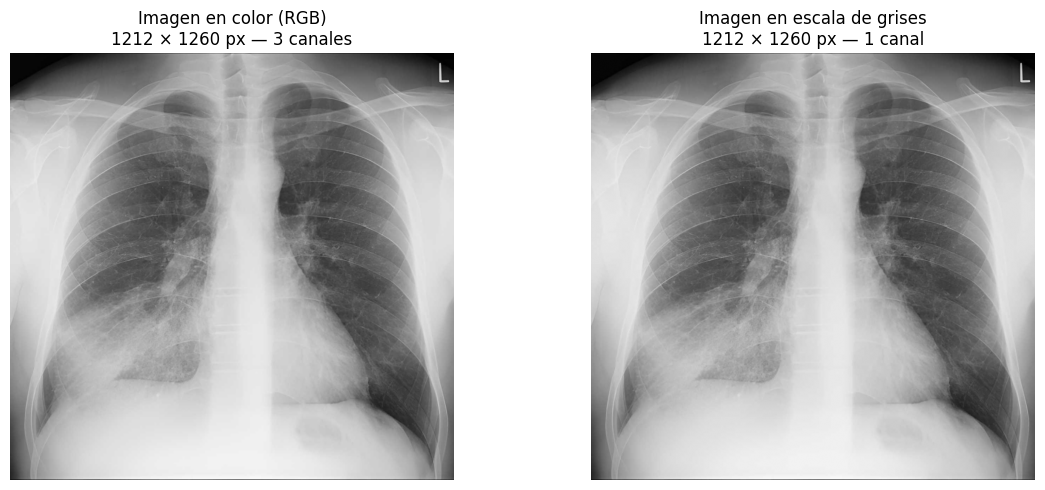

Guardado: paso3_carga.png


In [14]:
# ── Visualización: color y escala de grises ──────────────────────────────────
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.title(f'Imagen en color (RGB)\n{alto} × {ancho} px — {canales} canales')
plt.imshow(img_rgb)
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title(f'Imagen en escala de grises\n{img_gray.shape[0]} × {img_gray.shape[1]} px — 1 canal')
plt.imshow(img_gray, cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.savefig('paso3_carga.png', dpi=150, bbox_inches='tight')
plt.show()
print('Guardado: paso3_carga.png')

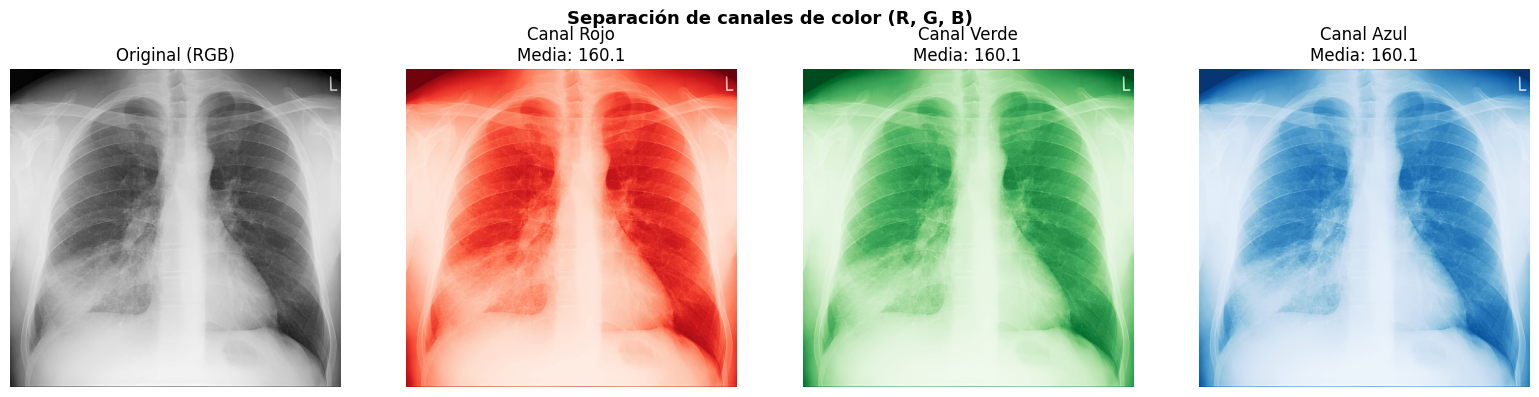

Guardado: paso3_canales.png


In [15]:
# ── Separación de canales RGB ────────────────────────────────────────────────
# Cada canal es una matriz 2D con la intensidad de ese color por píxel
canal_r = img_rgb[:, :, 0]
canal_g = img_rgb[:, :, 1]
canal_b = img_rgb[:, :, 2]

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle('Separación de canales de color (R, G, B)', fontsize=13, fontweight='bold')

axes[0].imshow(img_rgb)
axes[0].set_title('Original (RGB)'); axes[0].axis('off')

for ax, canal, tit, cm in zip(
    axes[1:],
    [canal_r, canal_g, canal_b],
    ['Canal Rojo', 'Canal Verde', 'Canal Azul'],
    ['Reds_r', 'Greens_r', 'Blues_r']
):
    ax.imshow(canal, cmap=cm)
    ax.set_title(f'{tit}\nMedia: {canal.mean():.1f}')
    ax.axis('off')

plt.tight_layout()
plt.savefig('paso3_canales.png', dpi=150, bbox_inches='tight')
plt.show()
print('Guardado: paso3_canales.png')

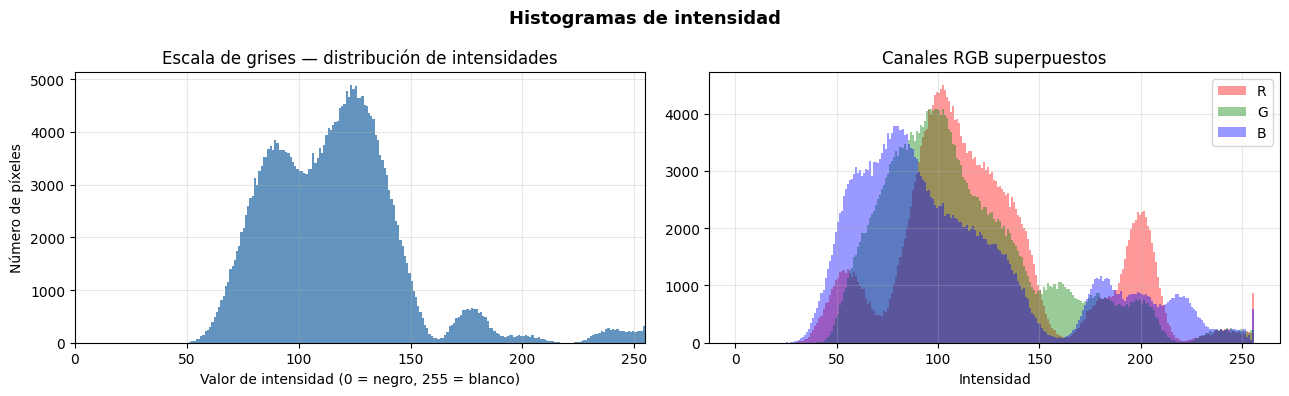

Guardado: paso3_histograma.png


In [5]:
# ── Histograma de intensidades ───────────────────────────────────────────────
# El histograma muestra cómo se distribuyen los valores de intensidad de 0 a 255
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Histogramas de intensidad', fontsize=13, fontweight='bold')

axes[0].hist(img_gray.ravel(), bins=256, range=(0, 256), color='steelblue', alpha=0.85)
axes[0].set_title('Escala de grises — distribución de intensidades')
axes[0].set_xlabel('Valor de intensidad (0 = negro, 255 = blanco)')
axes[0].set_ylabel('Número de píxeles')
axes[0].set_xlim(0, 255)
axes[0].grid(alpha=0.3)

for canal, color, label in zip(
    [canal_r, canal_g, canal_b], ['red', 'green', 'blue'], ['R', 'G', 'B']
):
    axes[1].hist(canal.ravel(), bins=256, range=(0, 256), color=color, alpha=0.4, label=label)
axes[1].set_title('Canales RGB superpuestos')
axes[1].set_xlabel('Intensidad')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('paso3_histograma.png', dpi=150, bbox_inches='tight')
plt.show()
print('Guardado: paso3_histograma.png')

### 📝 Registro del Paso 3 _(completa esta celda)_

**Dimensiones obtenidas:** ___ × ___ px  
**Tipo de dato:** ___  
**Rango de valores:** mínimo=___ / máximo=___ / promedio=___  
**Descripción de la escena observada:** ___  
**¿Qué diferencias observas entre la imagen en color y en escala de grises?** ___  
**¿Cuál canal RGB tiene mayor intensidad promedio en tu imagen y por qué?** ___

---
## PASO 4 — Aplicación de mejoras básicas
**Valor: 2% | Tiempo estimado: 1 hora**

Implementa al menos **dos mejoras básicas**: ajuste de brillo/contraste y suavizado o realce de bordes.  
Puedes modificar los parámetros para observar diferentes efectos.

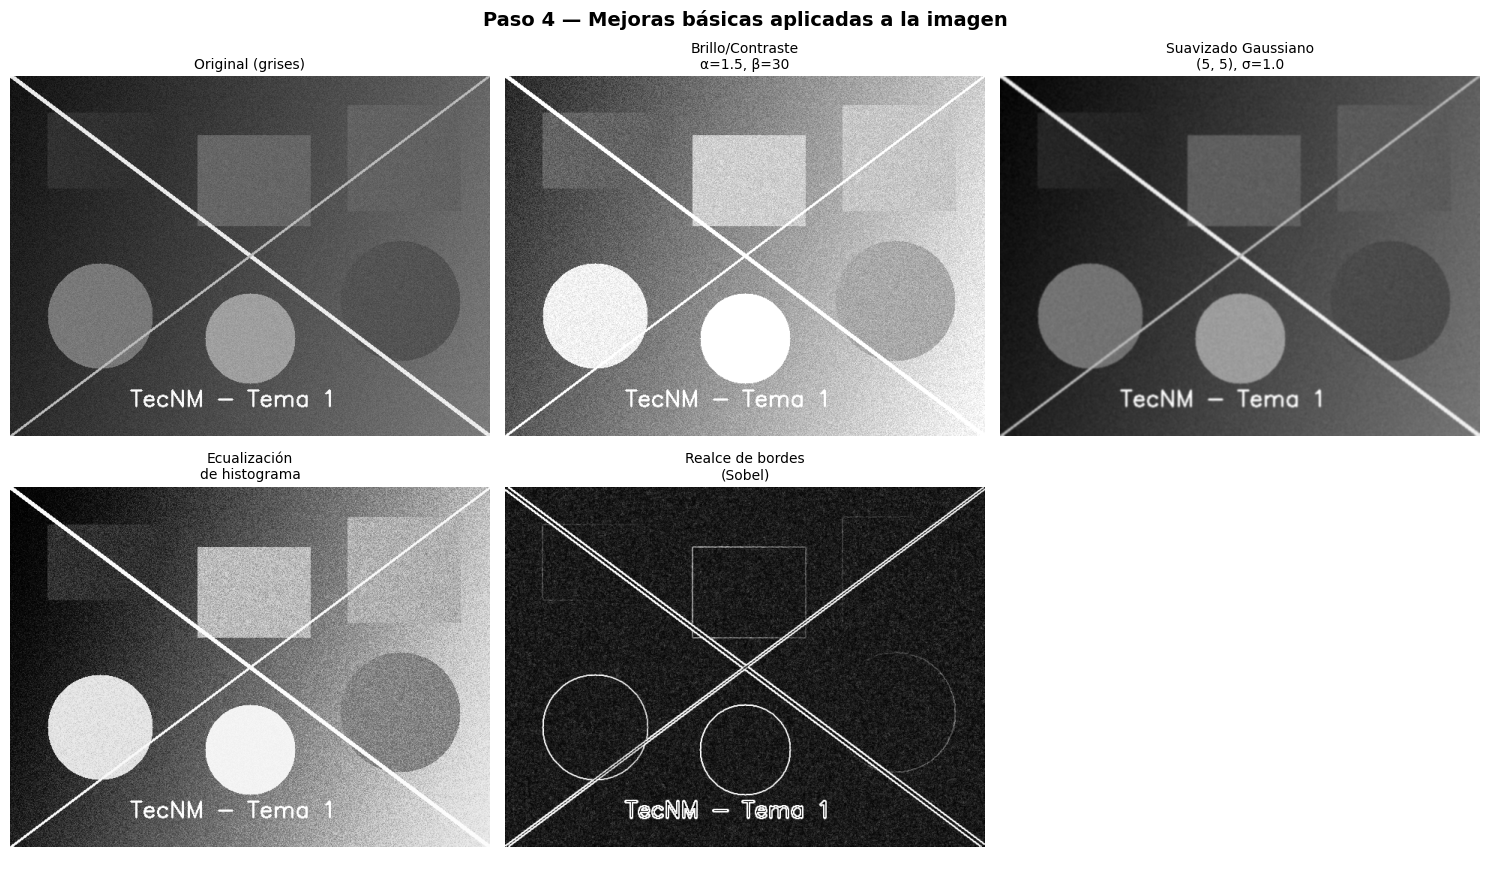

Parámetros utilizados:
  alpha (contraste)  : 1.5
  beta (brillo)      : 30
  kernel gaussiano   : (5, 5)
  sigma              : 1.0
  ksize Sobel        : 3×3
Guardado: paso4_mejoras.png


In [6]:
# ─── PARÁMETROS — modifica y observa los cambios ─────────────────────────────
ALPHA = 1.5      # Contraste: < 1 reduce, = 1 sin cambio, > 1 aumenta
BETA  = 30       # Brillo   : negativo oscurece, positivo ilumina
KERNEL_GAUSS = (5, 5)  # Tamaño del kernel gaussiano (debe ser impar × impar)
SIGMA = 1.0      # Desviación estándar del gaussiano (suavidad)

# ── 1) Ajuste de brillo y contraste ──────────────────────────────────────────
#    Fórmula: nueva_img[x,y] = alpha × img[x,y] + beta
#    cv2.convertScaleAbs garantiza valores en rango [0, 255]
img_brillo_contraste = cv2.convertScaleAbs(img_gray, alpha=ALPHA, beta=BETA)

# ── 2) Suavizado gaussiano ────────────────────────────────────────────────────
#    Reduce ruido mediante un promedio ponderado con distribución gaussiana
#    Útil antes de detección de bordes para evitar falsos positivos por ruido
img_suavizada = cv2.GaussianBlur(img_gray, KERNEL_GAUSS, SIGMA)

# ── 3) Ecualización de histograma ─────────────────────────────────────────────
#    Redistribuye los niveles de intensidad para aprovechar todo el rango [0, 255]
#    Mejora el contraste global, especialmente en imágenes oscuras o lavadas
img_ecualizada = cv2.equalizeHist(img_gray)

# ── 4) Realce de bordes con Sobel ─────────────────────────────────────────────
#    Calcula el gradiente de intensidad: detecta cambios bruscos (bordes)
#    Clave para entender las capas convolucionales de una CNN (Tema 3)
sobelx    = cv2.Sobel(img_gray, cv2.CV_64F, 1, 0, ksize=3)   # Gradiente horizontal
sobely    = cv2.Sobel(img_gray, cv2.CV_64F, 0, 1, ksize=3)   # Gradiente vertical
img_bordes = np.uint8(np.clip(cv2.magnitude(sobelx, sobely), 0, 255))  # Magnitud

# ── Visualización comparativa ─────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle('Paso 4 — Mejoras básicas aplicadas a la imagen', fontsize=14, fontweight='bold')

datos = [
    (img_gray,             'Original (grises)',                      None),
    (img_brillo_contraste, f'Brillo/Contraste\nα={ALPHA}, β={BETA}', None),
    (img_suavizada,        f'Suavizado Gaussiano\n{KERNEL_GAUSS}, σ={SIGMA}', None),
    (img_ecualizada,       'Ecualización\nde histograma',            None),
    (img_bordes,           'Realce de bordes\n(Sobel)',              None),
]
for ax, (img, tit, _) in zip(axes.ravel(), datos):
    ax.imshow(img, cmap='gray')
    ax.set_title(tit, fontsize=10)
    ax.axis('off')
axes[1, 2].axis('off')

plt.tight_layout()
plt.savefig('paso4_mejoras.png', dpi=150, bbox_inches='tight')
plt.show()

print('Parámetros utilizados:')
print(f'  alpha (contraste)  : {ALPHA}')
print(f'  beta (brillo)      : {BETA}')
print(f'  kernel gaussiano   : {KERNEL_GAUSS}')
print(f'  sigma              : {SIGMA}')
print(f'  ksize Sobel        : 3×3')
print('Guardado: paso4_mejoras.png')

---
## PASO 5 — Interpretación de los resultados
**Valor: 2% | Tiempo estimado: 1 hora**

Compara visualmente la imagen original con cada imagen mejorada.

### 📝 Análisis de resultados _(completa esta celda)_

**Ajuste de brillo y contraste (α=1.5, β=30):**  
_Describe qué cambios observas: ¿se pierden detalles? ¿mejora la visibilidad?_  

**Suavizado gaussiano:**  
_¿Qué ocurre con los bordes y el ruido de fondo?_  

**Ecualización de histograma:**  
_¿Mejora la visibilidad en zonas oscuras/claras? ¿En qué tipo de imagen es más útil?_  

**Realce de bordes (Sobel):**  
_¿Qué estructuras de la imagen se resaltan? ¿Por qué esto es útil en visión computacional?_  

---
### Reflexión (5-10 líneas):

**1. ¿En qué casos sería útil aumentar el contraste?**  
_(p. ej., imágenes médicas, ambientes con poca luz...)_  

**2. ¿Cuándo conviene suavizar una imagen antes de aplicar otros algoritmos?**  
_(p. ej., antes de detectar bordes, antes de segmentar...)_  

**3. ¿Cómo ayuda el realce de bordes en tareas de segmentación o detección de objetos?**  
_(conecta con lo que viste en la Presentación del Tema 1, sección 1.4)_

---
## PASO 6 — Extensión de la actividad
**Valor: 2% | Tiempo estimado: 2 horas**

Elige **al menos una** de las siguientes variantes y documenta lo aprendido al final.

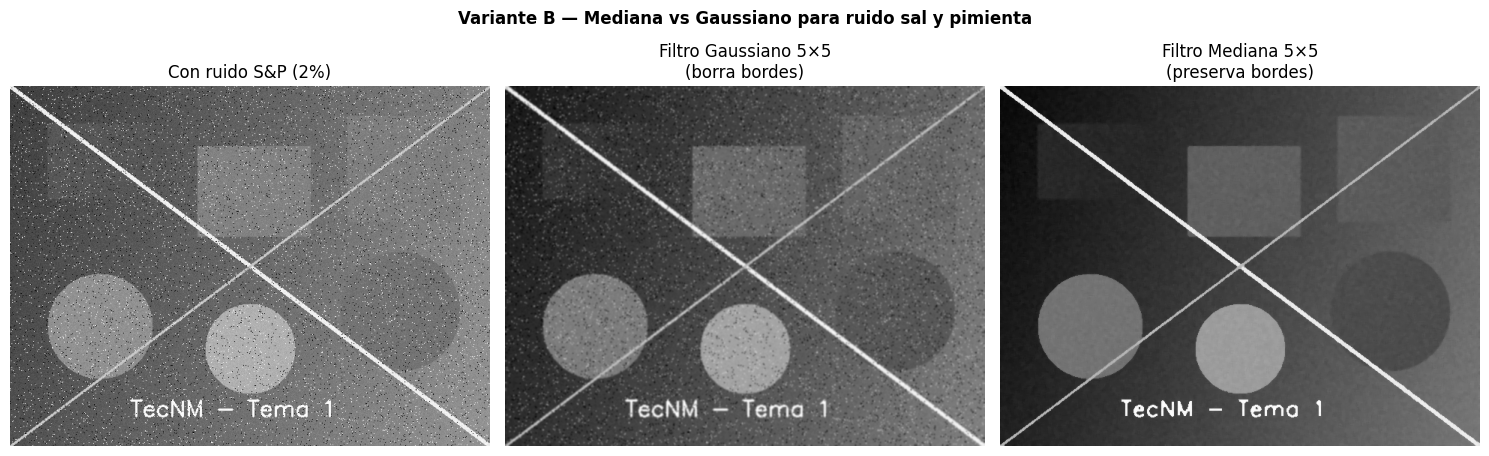

Observación: el filtro de mediana elimina el ruido S&P preservando mejor los bordes.


In [7]:
# ══ VARIANTE B — Filtro de mediana vs gaussiano (ruido sal y pimienta) ═══════
# Esta variante demuestra cuándo el filtro de mediana es superior al gaussiano

# Agregar ruido sal y pimienta artificialmente al 2% de los píxeles
np.random.seed(42)
img_ruidosa = img_gray.copy().astype(np.float32)
n_px = int(0.02 * img_gray.size)

coords_sal = [np.random.randint(0, d, n_px) for d in img_gray.shape]
img_ruidosa[coords_sal[0], coords_sal[1]] = 255   # sal (blanco)

coords_pim = [np.random.randint(0, d, n_px) for d in img_gray.shape]
img_ruidosa[coords_pim[0], coords_pim[1]] = 0     # pimienta (negro)
img_ruidosa = np.uint8(img_ruidosa)

img_mediana   = cv2.medianBlur(img_ruidosa, 5)           # Filtro de mediana 5×5
img_gaussiana = cv2.GaussianBlur(img_ruidosa, (5, 5), 1.0)  # Gaussiano 5×5

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Variante B — Mediana vs Gaussiano para ruido sal y pimienta',
             fontsize=12, fontweight='bold')
axes[0].imshow(img_ruidosa,   cmap='gray')
axes[0].set_title('Con ruido S&P (2%)'); axes[0].axis('off')
axes[1].imshow(img_gaussiana, cmap='gray')
axes[1].set_title('Filtro Gaussiano 5×5\n(borra bordes)'); axes[1].axis('off')
axes[2].imshow(img_mediana,   cmap='gray')
axes[2].set_title('Filtro Mediana 5×5\n(preserva bordes)'); axes[2].axis('off')
plt.tight_layout()
plt.savefig('paso6_variante_b.png', dpi=150, bbox_inches='tight')
plt.show()
print('Observación: el filtro de mediana elimina el ruido S&P preservando mejor los bordes.')

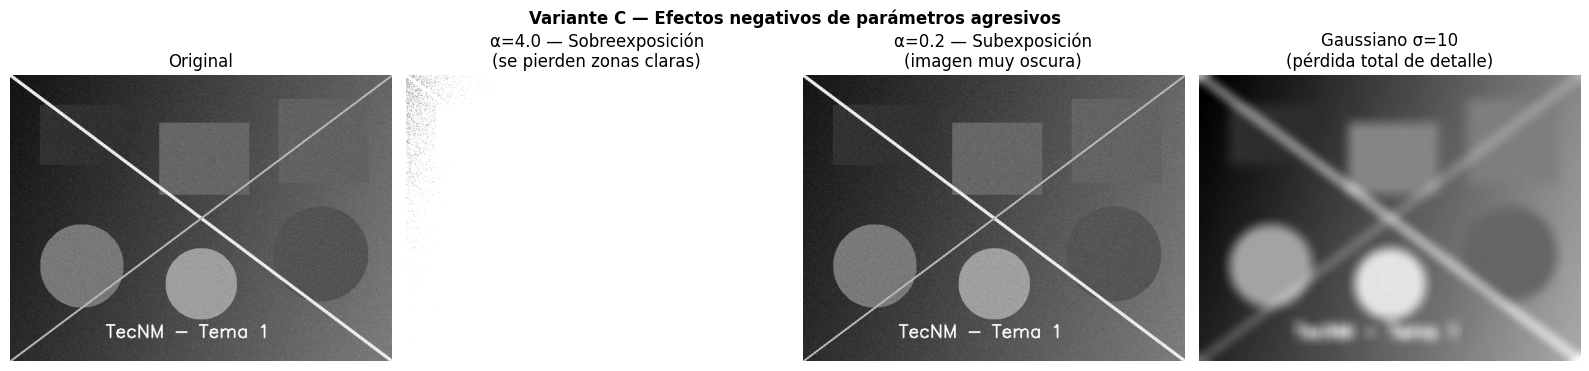

In [8]:
# ══ VARIANTE C — Efectos negativos de parámetros agresivos ═══════════════════
img_sobre   = cv2.convertScaleAbs(img_gray, alpha=4.0, beta=0)   # Sobreexposición
img_sub     = cv2.convertScaleAbs(img_gray, alpha=0.2, beta=0)   # Subexposición
img_borrosa = cv2.GaussianBlur(img_gray, (31, 31), 10.0)         # Pérdida de detalle

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle('Variante C — Efectos negativos de parámetros agresivos', fontsize=12, fontweight='bold')
axes[0].imshow(img_gray,    cmap='gray'); axes[0].set_title('Original'); axes[0].axis('off')
axes[1].imshow(img_sobre,   cmap='gray'); axes[1].set_title('α=4.0 — Sobreexposición\n(se pierden zonas claras)'); axes[1].axis('off')
axes[2].imshow(img_sub,     cmap='gray'); axes[2].set_title('α=0.2 — Subexposición\n(imagen muy oscura)'); axes[2].axis('off')
axes[3].imshow(img_borrosa, cmap='gray'); axes[3].set_title('Gaussiano σ=10\n(pérdida total de detalle)'); axes[3].axis('off')
plt.tight_layout()
plt.savefig('paso6_variante_c.png', dpi=150, bbox_inches='tight')
plt.show()

### 📝 Variante elegida y aprendizaje _(completa esta celda)_

**Variante seleccionada:** ☐ A &nbsp;&nbsp; ☐ B &nbsp;&nbsp; ☐ C

**¿Qué parámetros exploraste?** ___

**¿Qué aprendiste de esta extensión?** _(mínimo 3 líneas)_  

**Conexión con la idea del curso:** ¿Cómo afecta una mala etapa de adquisición/preprocesamiento al desempeño de un sistema de visión posterior (CNN)?  
_(conecta con lo que viste en la Presentación Tema 1, diapositiva "Conexión con temas posteriores")_

---
## REPORTE TÉCNICO — Portafolio de evidencias
_(Esta sección corresponde al Paso 7 del Manual del Participante)_

**Instrucciones:** Completa todos los campos. Este reporte, junto con las imágenes generadas, forma tu portafolio de evidencias del Tema 1.

---

### PORTADA

| | |
|---|---|
| **Nombre** | ___ |
| **Curso** | Redes Neuronales Convolucionales aplicadas a la Visión Computacional |
| **Tema** | 1 — Fundamentos de procesamiento digital de imágenes y visión |
| **Actividad** | T1.A1.1 — Adquisición y mejora básica de una imagen digital |
| **Fecha** | ___ |

---

### 1. Descripción de la imagen utilizada

| Campo | Valor |
|---|---|
| Nombre del archivo | ___ |
| Formato | ___ |
| Dimensiones | ___ × ___ px |
| Número de canales | ___ |
| Tipo de dato | ___ |
| Origen | ___ |
| Descripción de la escena | ___ |

---

### 2. Tabla de parámetros utilizados

| Técnica | Parámetro | Valor utilizado | Efecto |
|---|---|---|---|
| Brillo/Contraste | alpha | 1.5 | ___ |
| Brillo/Contraste | beta | 30 | ___ |
| Gaussiano | kernel | (5,5) | ___ |
| Gaussiano | sigma | 1.0 | ___ |
| Sobel | ksize | 3 | ___ |

---

### 3. Análisis comparativo de resultados

_Incluye las capturas generadas (`paso3_carga.png`, `paso3_canales.png`, `paso4_mejoras.png`)_

| Imagen | Observación principal |
|---|---|
| Original (grises) | Línea base de referencia |
| Brillo/Contraste | ___ |
| Suavizado gaussiano | ___ |
| Ecualización de histograma | ___ |
| Realce de bordes (Sobel) | ___ |

---

### 4. Reflexión final _(mínimo ½ cuartilla)_

**Importancia de una buena adquisición y preprocesamiento de imágenes:**  
_(escribe al menos 5 líneas)_

**Qué mejora resultó más útil para tu imagen concreta y por qué:**  
_Tu texto aquí_

**Posibles aplicaciones de estas operaciones en sistemas reales de visión por computadora:**  
_Tu texto aquí (menciona al menos 2 aplicaciones concretas)_

---

**Formato de entrega:** `T1_A1_ApellidoNombre.pdf` — máximo 2 MB  
**Plataforma:** Aula Virtual TecNM → Tarea Tema 1  
**Complemento (si el facilitador lo solicita):** enlace al notebook de Colab

---
## EVALUACIÓN FORMATIVA — Cuestionario en plataforma
**Peso: 10% | Tiempo: 1 hora**

El cuestionario se responde en el **Aula Virtual TecNM**. Temas evaluados:

| # | Tema |
|---|---|
| 1-3 | Imagen digital como matriz de píxeles |
| 4-5 | Parámetros de adquisición: resolución, profundidad de bits, fps |
| 6-7 | Modelos de color: escala de grises y RGB |
| 8-10 | Mejoras básicas de imagen: brillo, contraste, suavizado, bordes |

> 10 reactivos de opción múltiple · 30 minutos · **2 intentos** · Se considera la calificación más alta

---
**Recursos de apoyo para el cuestionario:**
- Presentación "Tema 1. Fundamentos de procesamiento digital de imágenes y visión"
- Manual del Participante – Tema 1
- Este notebook con tus resultados y reflexiones

In [9]:
# ── Resumen de archivos generados ────────────────────────────────────────────
archivos = [
    ('paso3_carga.png',       'Visualización color y grises'),
    ('paso3_canales.png',     'Separación canales R, G, B'),
    ('paso3_histograma.png',  'Histogramas de intensidad'),
    ('paso4_mejoras.png',     'Mejoras básicas comparadas'),
    ('paso6_variante_b.png',  'Extensión: Mediana vs Gaussiano'),
    ('paso6_variante_c.png',  'Extensión: Efectos agresivos'),
]
print('ARCHIVOS GENERADOS PARA EL PORTAFOLIO:')
print('-' * 55)
for archivo, descripcion in archivos:
    existe = '✅' if os.path.exists(archivo) else '⬜  (aún no generado)'
    print(f'  {existe}  {archivo:<30} {descripcion}')
print('-' * 55)
print('\nSiguiente paso: exporta este notebook como PDF')
print('Nombre de entrega: T1_A1_ApellidoNombre.pdf')

ARCHIVOS GENERADOS PARA EL PORTAFOLIO:
-------------------------------------------------------
  ✅  paso3_carga.png                Visualización color y grises
  ✅  paso3_canales.png              Separación canales R, G, B
  ✅  paso3_histograma.png           Histogramas de intensidad
  ✅  paso4_mejoras.png              Mejoras básicas comparadas
  ✅  paso6_variante_b.png           Extensión: Mediana vs Gaussiano
  ✅  paso6_variante_c.png           Extensión: Efectos agresivos
-------------------------------------------------------

Siguiente paso: exporta este notebook como PDF
Nombre de entrega: T1_A1_ApellidoNombre.pdf
